# Bevölkerung der Stadt Zürich


### Kurzbeschreibung
Wirtschaftliche Wohnbevölkerung der Stadt Zürich nach Jahr.

Datum: 04.02.205

bev_bestand_jahr_od3243


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_od3243


Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_od3243


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bev_bestand_jahr_od3243"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV324OD3243"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_od3243/download/BEV324OD3243.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_od3243 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_bestand_jahr_od3243 

data_source: web


In [10]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1901-01-01 00:00:00,1902-01-01 00:00:00
AnzBestWir,150301,153741


Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

In [12]:
data2betested.head(2).T

,123,122
StichtagDatJahr,2024-01-01 00:00:00,2023-01-01 00:00:00
AnzBestWir,448664,447082
StichtagDatJahr_str,2024-01-01,2023-01-01
Jahr,2024-01-01 00:00:00,2023-01-01 00:00:00
Jahr_end,2024-12-31 00:00:00,2023-12-31 00:00:00
Jahr_nbr,2024,2023


Minimales und maximales Jahr im Datensatz

In [13]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1901 und ein Maximumjahr von 2024


In [14]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1901-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [15]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 123 to 0
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      124 non-null    datetime64[ns]
 1   AnzBestWir           124 non-null    int64         
 2   StichtagDatJahr_str  124 non-null    object        
 3   Jahr                 124 non-null    datetime64[ns]
 4   Jahr_end             124 non-null    datetime64[ns]
 5   Jahr_nbr             124 non-null    int32         
dtypes: datetime64[ns](3), int32(1), int64(1), object(1)
memory usage: 13.4 KB


In [16]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 124 rows (observations) and 6 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [17]:
data2betested.describe()

,StichtagDatJahr,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,124,124,124,124,124
mean,1962-07-02 12:00:00,337441,1962-07-02 12:00:00,1963-07-01 18:00:00,1962
min,1901-01-01 00:00:00,150301,1901-01-01 00:00:00,1901-12-31 00:00:00,1901
25%,1931-10-01 18:00:00,259890,1931-10-01 18:00:00,1932-09-30 12:00:00,1932
50%,1962-07-02 12:00:00,361768,1962-07-02 12:00:00,1963-07-01 12:00:00,1962
75%,1993-04-02 06:00:00,403914,1993-04-02 06:00:00,1994-04-01 06:00:00,1993
max,2024-01-01 00:00:00,448664,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,87963,NaN,NaN,36


Welches sind die Quartiere ohne Werte bei BEW?

In [18]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [19]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [20]:
data2betested.index.year.unique()

Index([1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910,
       ...
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr', length=124)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [21]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,StichtagDatJahr_str,Jahr,Jahr_end
count,124,124,124
unique,124,NaN,NaN
top,1901-01-01,NaN,NaN
freq,1,NaN,NaN
mean,NaN,1962-07-02 12:00:00,1963-07-01 18:00:00
min,NaN,1901-01-01 00:00:00,1901-12-31 00:00:00
25%,NaN,1931-10-01 18:00:00,1932-09-30 12:00:00
50%,NaN,1962-07-02 12:00:00,1963-07-01 12:00:00
75%,NaN,1993-04-02 06:00:00,1994-04-01 06:00:00
max,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [22]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AnzBestWir,Jahr_nbr
count,124,124
mean,"337,441","1,962"
std,"87,963",36
min,"150,301","1,901"
25%,"259,890","1,932"
50%,"361,768","1,962"
75%,"403,914","1,993"
max,"448,664","2,024"


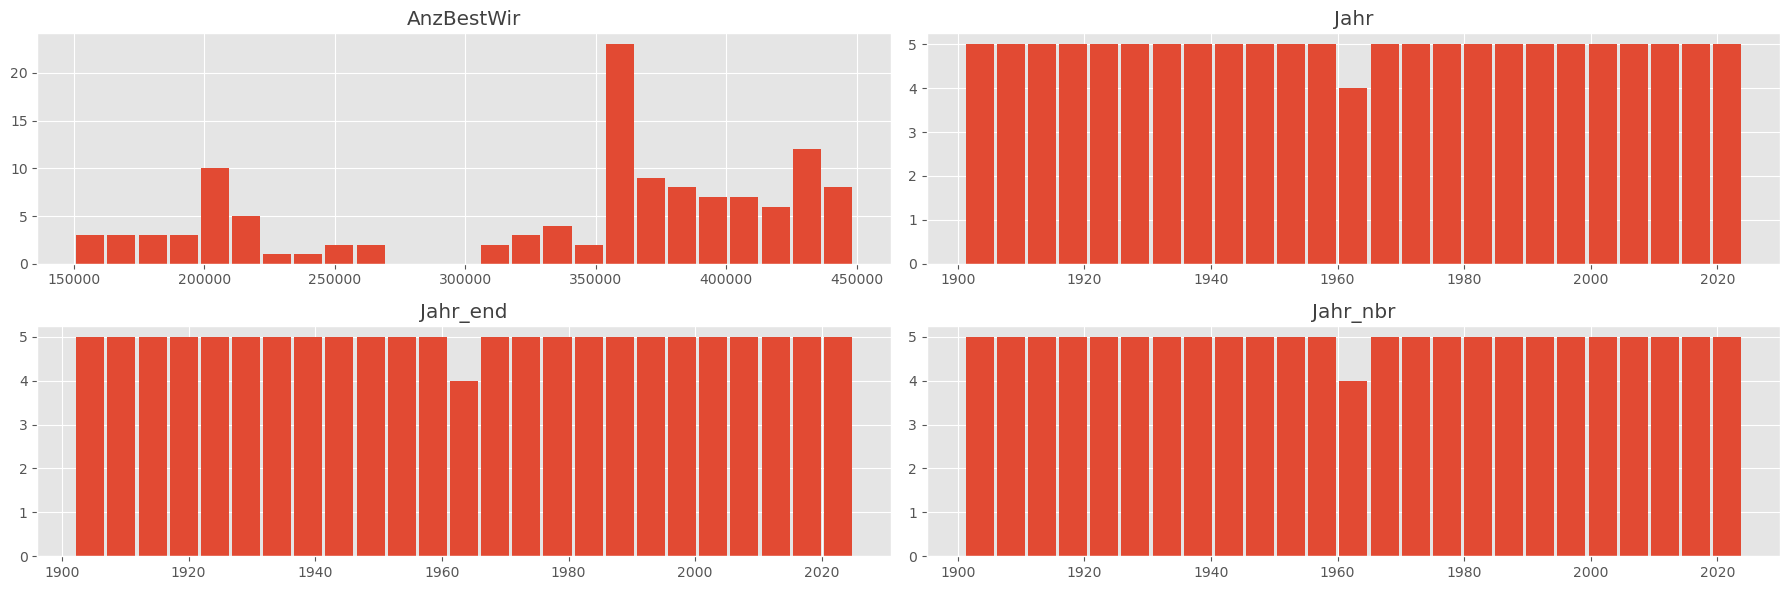

In [23]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [24]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,


### Nullwerte und Missings?

In [25]:
data2betested.isnull().sum()

AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [26]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [27]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2024-01-01,2024,2024-12-31,448664
1,2023-01-01,2023,2023-12-31,447082
2,2022-01-01,2022,2022-12-31,443037


In [28]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'], dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Wohnbevölkerung nach Quartier

In [29]:
#data2betested.loc[data_min_date:'1970']\
#     .query('QuarSort < 40')\
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,sum_WBev
0,1902-01-01,153741
1,1903-01-01,158719
2,1904-01-01,164060


In [30]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    #,category = "KreisLang:N"
    #,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Wohnbevölkerung, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [31]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik1)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik1, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [32]:
myFG = data2betested.reset_index()
myFG

,StichtagDatJahr,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1901-01-01,150301,1901-01-01,1901-01-01,1901-12-31,1901
1,1902-01-01,153741,1902-01-01,1902-01-01,1902-12-31,1902
2,1903-01-01,158719,1903-01-01,1903-01-01,1903-12-31,1903
3,1904-01-01,164060,1904-01-01,1904-01-01,1904-12-31,1904
4,1905-01-01,168877,1905-01-01,1905-01-01,1905-12-31,1905
...,...,...,...,...,...,...
119,2020-01-01,434736,2020-01-01,2020-01-01,2020-12-31,2020
120,2021-01-01,436332,2021-01-01,2021-01-01,2021-12-31,2021
121,2022-01-01,443037,2022-01-01,2022-01-01,2022-12-31,2022
122,2023-01-01,447082,2023-01-01,2023-01-01,2023-12-31,2023


In [33]:
data2betested.columns

Index(['AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'], dtype='object')

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1234&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------